# HamLeT — Hamiltonian Learning Toolkit: supervised workflow test

This notebook is an executable test of the package's two initial workflows:

1. bond-inhomogeneous Heisenberg chains using local three-site windows;
2. homogeneous $J_1$-$J_2$ chains using a global full-spectrum view.

A fast deterministic simulator is used to generate enough examples for training. The final section runs the real DMRGPy backend on a very small chain.

In [1]:
from pathlib import Path
import sys
import tempfile

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np

from hamlet.benchmarks import mae, rmse
from hamlet.data import SpectroscopyDataset, as_supervised, generate_dataset
from hamlet.models import (
    CNNConfig, MLPConfig, available_supervised_models, create_supervised_model,
)
from hamlet.preprocessing import make_local_windows, reconstruct_chain
from hamlet.simulation import (
    DmrgpySimulator, SpectroscopyProtocol, SpectroscopyResult,
)
from hamlet.systems import (
    HomogeneousHeisenbergChain, HomogeneousHeisenbergFamily,
    InhomogeneousHeisenbergChain, InhomogeneousHeisenbergFamily,
)
from hamlet.training import MinMaxTargetScaler, grouped_split

print('Available models:', available_supervised_models())

Available models: ('keras_mlp', 'keras_cnn', 'ridge', 'random_forest')


## Fast test simulator

The simulator below is deliberately inexpensive. It creates site spectra with known coupling-dependent basis functions. It tests sampling, metadata, shapes, local/global views, splitting, scaling, training, and reconstruction without launching thousands of DMRG calculations.

In [2]:
class FastSpectroscopySimulator:
    def simulate(self, system, protocol):
        bias = np.asarray(protocol.bias_mev, dtype=float)
        x = (bias - bias.min()) / (bias.max() - bias.min())
        spectra = []

        if isinstance(system, InhomogeneousHeisenbergChain):
            bonds = system.as_array()
            for site in range(system.n_sites):
                left = bonds[site - 1] if site > 0 else 0.0
                right = bonds[site] if site < system.n_sites - 1 else 0.0
                spectrum = (
                    left * np.sin(np.pi * x)
                    + right * np.cos(0.5 * np.pi * x)
                    + 0.05 * (left + right) * x
                )
                spectra.append(spectrum)
        elif isinstance(system, HomogeneousHeisenbergChain):
            couplings = system.as_array()
            for site in range(system.n_sites):
                spectrum = np.zeros_like(x)
                for distance, coupling in enumerate(couplings, start=1):
                    spectrum += coupling * np.sin(distance * np.pi * x)
                spectrum += 0.01 * site * couplings.sum() * x
                spectra.append(spectrum)
        else:
            raise TypeError(type(system))

        return SpectroscopyResult(bias, np.stack(spectra))

protocol = SpectroscopyProtocol.uniform((0.0, 10.0), points=80)
fast_simulator = FastSpectroscopySimulator()

## 1. Bond-inhomogeneous model

A length-12 physical dataset is converted to local examples. Grouped splitting keeps every window from a simulated chain in exactly one partition.

In [3]:
inhomogeneous_family = InhomogeneousHeisenbergFamily(
    n_sites=12, coupling_range_mev=(3.0, 4.0)
)
inhomogeneous = generate_dataset(
    inhomogeneous_family, fast_simulator, protocol, n_samples=160, seed=42
)
local = as_supervised(inhomogeneous, view='local_bonds')
local_split = grouped_split(local, validation_fraction=0.2, test_fraction=0.15, seed=42)
local_scaler = MinMaxTargetScaler.fit(local_split.train.targets)

local_model = create_supervised_model(
    'ridge', local.inputs.shape[1], local.targets.shape[1], alpha=1e-6, solver='lsqr'
)
local_model.fit(local_split.train.inputs, local_scaler.transform(local_split.train.targets))
local_pred = local_scaler.inverse_transform(local_model.predict(local_split.test.inputs))

print('Physical dataset:', inhomogeneous.spectra.shape, inhomogeneous.targets_mev.shape)
print('Local supervised view:', local.inputs.shape, local.targets.shape)
print('Held-out MAE [meV]:', mae(local_pred, local_split.test.targets))
print('Held-out RMSE [meV]:', rmse(local_pred, local_split.test.targets))
assert set(local_split.train.group_ids).isdisjoint(set(local_split.test.group_ids))

Physical dataset: (160, 12, 80) (160, 11)
Local supervised view: (1600, 240) (1600, 2)
Held-out MAE [meV]: 5.155801545697614e-07
Held-out RMSE [meV]: 5.725356686525629e-07


### Apply the local model to a different chain length

The estimator was trained on length 12. Here it reconstructs all seven bonds of a new length-8 chain.

Training length: 12; inference length: 8
True bonds:          [3.6824 3.0538 3.2204 3.1844 3.1759 3.8121 3.9233]
Reconstructed bonds: [3.6824 3.0538 3.2204 3.1844 3.1759 3.8121 3.9233]
Chain MAE [meV]: 5.449567765936081e-07


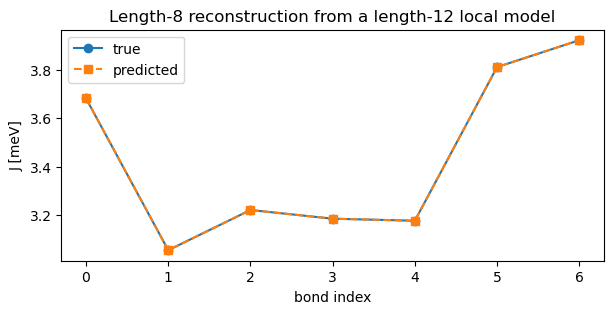

In [4]:
different_length = generate_dataset(
    InhomogeneousHeisenbergFamily(8, (3.0, 4.0)),
    fast_simulator, protocol, n_samples=1, seed=123,
)
windows = make_local_windows(different_length.spectra)[0]
window_predictions = local_scaler.inverse_transform(local_model.predict(windows))
reconstructed = reconstruct_chain(window_predictions)
truth = different_length.targets_mev[0]

print('Training length: 12; inference length:', different_length.n_sites)
print('True bonds:         ', np.round(truth, 4))
print('Reconstructed bonds:', np.round(reconstructed, 4))
print('Chain MAE [meV]:', mae(reconstructed, truth))
assert reconstructed.shape == (different_length.n_sites - 1,)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(truth, 'o-', label='true')
ax.plot(reconstructed, 's--', label='predicted')
ax.set(xlabel='bond index', ylabel='J [meV]', title='Length-8 reconstruction from a length-12 local model')
ax.legend();
plt.show()

## 2. Homogeneous global $J_1$-$J_2$ model

For this family, `J1` is shared by all nearest-neighbor pairs and `J2` by all next-nearest-neighbor pairs. The targets are global, so each full chain is one supervised example.

Targets: ('J1', 'J2')
Global supervised view: (160, 800) (160, 2)
Held-out MAE [meV]: 6.292636385296646e-07
Held-out RMSE [meV]: 8.00593340954947e-07


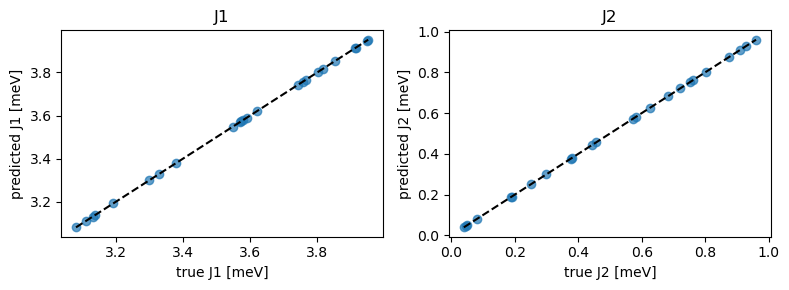

In [5]:
homogeneous_family = HomogeneousHeisenbergFamily(
    n_sites=10,
    coupling_ranges_mev=((3.0, 4.0), (0.0, 1.0)),
)
homogeneous = generate_dataset(
    homogeneous_family, fast_simulator, protocol, n_samples=160, seed=7
)
global_data = as_supervised(homogeneous, view='global')
global_split = grouped_split(global_data, validation_fraction=0.2, test_fraction=0.15, seed=7)
global_scaler = MinMaxTargetScaler.fit(global_split.train.targets)
global_model = create_supervised_model(
    'ridge', global_data.inputs.shape[1], global_data.targets.shape[1], alpha=1e-6, solver='lsqr'
)
global_model.fit(global_split.train.inputs, global_scaler.transform(global_split.train.targets))
global_pred = global_scaler.inverse_transform(global_model.predict(global_split.test.inputs))

print('Targets:', homogeneous.target_names)
print('Global supervised view:', global_data.inputs.shape, global_data.targets.shape)
print('Held-out MAE [meV]:', mae(global_pred, global_split.test.targets))
print('Held-out RMSE [meV]:', rmse(global_pred, global_split.test.targets))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, name in enumerate(homogeneous.target_names):
    axes[i].scatter(global_split.test.targets[:, i], global_pred[:, i], alpha=0.7)
    limits = [global_split.test.targets[:, i].min(), global_split.test.targets[:, i].max()]
    axes[i].plot(limits, limits, 'k--')
    axes[i].set(xlabel=f'true {name} [meV]', ylabel=f'predicted {name} [meV]', title=name)
plt.tight_layout();
plt.show()

## Dataset persistence

The saved NPZ contains spectra, targets, bias grid, units-related naming, simulator settings, random seed, and system type.

In [6]:
with tempfile.TemporaryDirectory() as directory:
    path = Path(directory) / 'homogeneous_j1_j2.npz'
    homogeneous.save(path)
    restored = SpectroscopyDataset.load(path)

np.testing.assert_allclose(restored.spectra, homogeneous.spectra)
np.testing.assert_allclose(restored.targets_mev, homogeneous.targets_mev)
print('Round-trip successful:', restored.n_samples, 'samples')
print('Metadata:', restored.metadata)

Round-trip successful: 160 samples
Metadata: {'seed': 7, 'n_samples': 160, 'protocol': {'broadening_mev': 0.05, 'observable': 'Sz', 'output_quantity': 'spectral_function'}, 'simulator': 'FastSpectroscopySimulator', 'family': 'HomogeneousHeisenbergFamily'}


## Real DMRGPy smoke test

This intentionally tiny calculation verifies that the package builds a real homogeneous $J_1$-$J_2$ Hamiltonian, evaluates site-resolved dynamical correlators, and converts them to the integrated `dI/dV` convention used by the reference project.

DMRGPy output shape: (3, 16)
All values finite: True


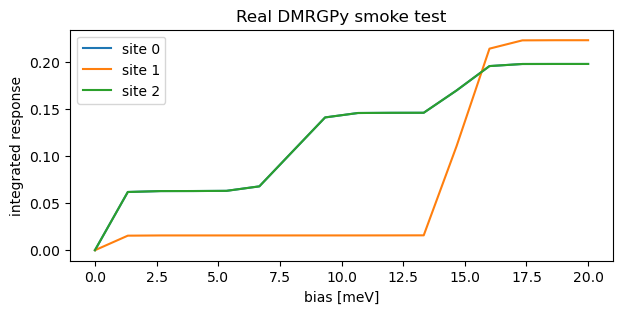

In [7]:
dmrg_system = HomogeneousHeisenbergChain(3, [10.0, 2.0])
dmrg_protocol = SpectroscopyProtocol.uniform(
    (0.0, 20.0), points=16, broadening_mev=1.0, output_quantity='didv'
)
with tempfile.TemporaryDirectory() as directory:
    previous = Path.cwd()
    try:
        import os
        os.chdir(directory)
        dmrg_result = DmrgpySimulator(
            max_bond_dimension=10, kpm_max_bond_dimension=10
        ).simulate(dmrg_system, dmrg_protocol)
    finally:
        os.chdir(previous)

print('DMRGPy output shape:', dmrg_result.spectral_map.shape)
print('All values finite:', np.isfinite(dmrg_result.spectral_map).all())
assert dmrg_result.spectral_map.shape == (3, 16)
assert np.isfinite(dmrg_result.spectral_map).all()

fig, ax = plt.subplots(figsize=(7, 3))
for site, values in enumerate(dmrg_result.spectral_map):
    ax.plot(dmrg_result.bias_mev, values, label=f'site {site}')
ax.set(xlabel='bias [meV]', ylabel='integrated response', title='Real DMRGPy smoke test')
ax.legend();
plt.show()

## Select an MLP or CNN architecture

Both neural models consume the same flattened supervised arrays. The CNN additionally receives the original `(sites, bias_points)` shape and convolves along bias with sites as channels. Configuration objects make tuning choices explicit and serializable.

In [8]:
mlp_config = MLPConfig(
    hidden_units=(256, 128), dropout=0.2, l2=1e-4, learning_rate=3e-4
)
cnn_config = CNNConfig(
    filters=(16, 32), kernel_size=7, dense_units=(64,), dropout=0.2
)

example_mlp = create_supervised_model(
    'keras_mlp', local.inputs.shape[1], local.targets.shape[1], config=mlp_config
)
example_cnn = create_supervised_model(
    'keras_cnn', local.inputs.shape[1], local.targets.shape[1],
    spectrum_shape=(3, protocol.bias_mev.size), config=cnn_config,
)
assert example_mlp.output_shape == example_cnn.output_shape == (None, 2)
print('MLP parameters:', example_mlp.count_params())
print('CNN parameters:', example_cnn.count_params())
print('CNN input/output:', example_cnn.input_shape, example_cnn.output_shape)

2026-08-18 15:18:59.724429: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-18 15:18:59.725172: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-18 15:18:59.847709: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-18 15:19:03.358958: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

MLP parameters: 95874
CNN parameters: 6402
CNN input/output: (None, 240) (None, 2)


## Result

The notebook has exercised the full initial stack: parameter sampling → simulation → portable dataset → supervised representation → leakage-safe split → target scaling → selectable regression model → held-out benchmark → variable-length reconstruction, followed by a real DMRGPy calculation.